### SDXL text encoder test

We found that Flux text encoder is very large and it's embeddings are large too. 

So both pre-computing them and computing during training is impractical.

Let's see if we can use some smaller text encoder from another model, say, SDXL.

SDXL has two text encoders, but there embedding format is different:
1) CLIP ViT-L encoder (768-dimensional token embeddings)
2) CLIP ViT-bigG encoder (1280-dimensional token embeddings)

In this notebook we:
1) load all SDXL pipeline parts
2) show how to compute embeddings separately from other parts
3) decide which encoder do we need
4) run SDXL pipeline manually to ensure embeddings are calculated correctly

In [1]:
from diffusers import UNet2DConditionModel
from safetensors.torch import load_file
import torch
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
from torchvision import transforms
from diffusers import EulerDiscreteScheduler
from transformers import CLIPTextModel, CLIPTokenizer, CLIPTextModelWithProjection
from diffusers import AutoencoderKL

In [2]:
unet = UNet2DConditionModel.from_pretrained(
    "../stable-diffusion-xl-base-1.0/unet",
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True
).to("cuda")

text_encoder = CLIPTextModel.from_pretrained("../stable-diffusion-xl-base-1.0/text_encoder").to("cuda", torch.float16)
text_encoder_2 = CLIPTextModelWithProjection.from_pretrained("../stable-diffusion-xl-base-1.0/text_encoder_2").to("cuda", torch.float16)

tokenizer = CLIPTokenizer.from_pretrained("../stable-diffusion-xl-base-1.0/tokenizer")
tokenizer_2 = CLIPTokenizer.from_pretrained("../stable-diffusion-xl-base-1.0/tokenizer_2")

scheduler = EulerDiscreteScheduler.from_pretrained("../stable-diffusion-xl-base-1.0/scheduler", timestep_spacing="trailing")

vae = AutoencoderKL.from_pretrained("../stable-diffusion-xl-base-1.0/vae").to("cuda")

vae = vae.eval()

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

In [3]:
prompt = "A detailed photorealistic photo of a white cat on the green grass, colorful, macro, hd, 4k"

inputs_1 = tokenizer(
    prompt,
    padding="max_length",
    truncation=True,
    max_length=tokenizer.model_max_length,
    return_tensors="pt"
).to("cuda")

inputs_2 = tokenizer_2(
    prompt,
    padding="max_length",
    truncation=True,
    max_length=tokenizer_2.model_max_length,
    return_tensors="pt"
).to("cuda")

In [4]:
with torch.no_grad():
    enc1 = text_encoder(
        inputs_1.input_ids,
        output_hidden_states=True,
        return_dict=True,
    )
    enc2 = text_encoder_2(
        inputs_2.input_ids,
        output_hidden_states=True,
        return_dict=True,
    )

In [5]:
print(enc1.last_hidden_state.shape)
print(enc2.last_hidden_state.shape)
print(enc2.text_embeds.shape)

text_embeds = enc2.text_embeds

# the most intresting part
enc1_tokens = enc1.hidden_states[-2]
enc2_tokens = enc2.hidden_states[-2]
encoder_hidden_states = torch.cat([enc1_tokens, enc2_tokens], dim=-1)

# these two are passed to the model
print(text_embeds.shape) 
print(encoder_hidden_states.shape)

torch.Size([1, 77, 768])
torch.Size([1, 77, 1280])
torch.Size([1, 1280])
torch.Size([1, 1280])
torch.Size([1, 77, 2048])


So, we have:

| tensor                 | comes from      | shape             | meaning                                                 |
|------------------------|-----------------|-------------------|---------------------------------------------------------|
|text_embeds             | encoder 2 only  | [1, 1280]         | single vector describing whole image                    |
|encoder_hidden_states   | encoder 1 and 2 | [1, 77, 2048]     | a vector per text token, detailed prompt representation |

And we likely need **text_embeds** only as it weights less in memory

In [6]:
n = 591753
print("text_embeds weight", n * 1280 * 2 / 1024 / 1024 / 1024, "GB") 
print("encoder_hidden_states weight", n * 77 * 2048 * 2 / 1024 / 1024 / 1024, "GB") 

text_embeds weight 1.4108490943908691 GB
encoder_hidden_states weight 173.81660842895508 GB


### SDXL run

This is just some glue code that runs SDXL manually with the computed text embeddings to check that we made everything correct

In [7]:
time_ids = torch.tensor([[1024, 1024, 0, 0, 1024, 1024]], dtype=torch.float16, device="cuda")

In [8]:
scheduler.set_timesteps(50)
print(scheduler.timesteps)
print(scheduler.init_noise_sigma)

tensor([999., 979., 959., 939., 919., 899., 879., 859., 839., 819., 799., 779.,
        759., 739., 719., 699., 679., 659., 639., 619., 599., 579., 559., 539.,
        519., 499., 479., 459., 439., 419., 399., 379., 359., 339., 319., 299.,
        279., 259., 239., 219., 199., 179., 159., 139., 119.,  99.,  79.,  59.,
         39.,  19.])
tensor(14.6146)


In [9]:
generator = torch.Generator(device="cuda").manual_seed(67)
latents = torch.normal(0, 1, (1, 4, 128, 128), dtype=torch.float16, device="cuda", generator=generator)
latents = latents * scheduler.init_noise_sigma

In [10]:
with torch.no_grad():
    for t in scheduler.timesteps:
        latent_model_input = scheduler.scale_model_input(latents, t)
       
    
        noise_pred = unet(
            latent_model_input,
            t,
            encoder_hidden_states=encoder_hidden_states,
            added_cond_kwargs={
                "text_embeds": text_embeds,
                "time_ids": time_ids,
            },
            return_dict=False,
        )[0]

        latents = scheduler.step(
            noise_pred,
            t,
            latents,
        ).prev_sample

tensor(-1.9746, device='cuda:0', dtype=torch.float16) tensor(2.2090, device='cuda:0', dtype=torch.float16)
torch.Size([1, 3, 1024, 1024])


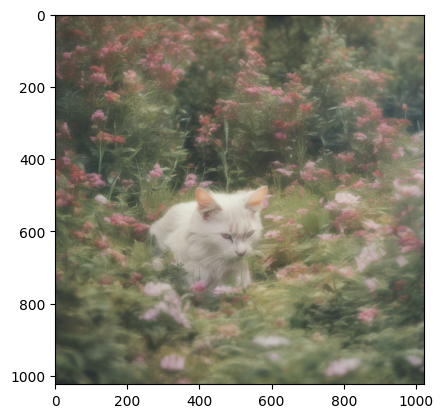

In [11]:
print(latents.min(), latents.max())
with torch.no_grad():
    image = (vae.decode(latents.float() / vae.config.scaling_factor).sample + 1.0) / 2.0
print(image.shape)

image = image.squeeze(0).permute((1, 2, 0)).float().cpu().numpy()
image = np.clip(image, 0, 1)

plt.imshow(image)
plt.show()

### enable CFG

Add classifier free guidance to make image more expressive

In [12]:
negative_prompt = "blurry, undetailed, low quality"

inputs_1 = tokenizer(
    negative_prompt,
    padding="max_length",
    truncation=True,
    max_length=tokenizer.model_max_length,
    return_tensors="pt"
).to("cuda")

inputs_2 = tokenizer_2(
    negative_prompt,
    padding="max_length",
    truncation=True,
    max_length=tokenizer_2.model_max_length,
    return_tensors="pt"
).to("cuda")

with torch.no_grad():
    enc1 = text_encoder(
        inputs_1.input_ids,
        output_hidden_states=True,
        return_dict=True,
    )
    enc2 = text_encoder_2(
        inputs_2.input_ids,
        output_hidden_states=True,
        return_dict=True,
    )

negative_text_embeds = enc2.text_embeds

enc1_tokens = enc1.hidden_states[-2]
enc2_tokens = enc2.hidden_states[-2]

negative_encoder_hidden_states = torch.cat([enc1_tokens, enc2_tokens], dim=-1)

In [13]:
scheduler.set_timesteps(50)
latents = torch.normal(0, 1, (1, 4, 128, 128), dtype=torch.float16, device="cuda", generator=generator)
latents = latents * scheduler.init_noise_sigma

cfg = 7.0

with torch.no_grad():
    for t in scheduler.timesteps:
        latent_model_input = scheduler.scale_model_input(latents, t)
    
        noise_pred = unet(
            latent_model_input,
            t,
            encoder_hidden_states=encoder_hidden_states,
            added_cond_kwargs={
                "text_embeds": text_embeds,
                "time_ids": time_ids,
            },
            return_dict=False,
        )[0]


        negative_noise_pred = unet(
            latent_model_input,
            t,
            encoder_hidden_states=negative_encoder_hidden_states,
            added_cond_kwargs={
                "text_embeds": negative_text_embeds,
                "time_ids": time_ids,
            },
            return_dict=False,
        )[0]

        cfg_noise_pred = negative_noise_pred + (noise_pred - negative_noise_pred) * cfg
    
        latents = scheduler.step(
            cfg_noise_pred,
            t,
            latents,
        ).prev_sample

tensor(-2.3164, device='cuda:0', dtype=torch.float16) tensor(3.2871, device='cuda:0', dtype=torch.float16)
torch.Size([1, 3, 1024, 1024])


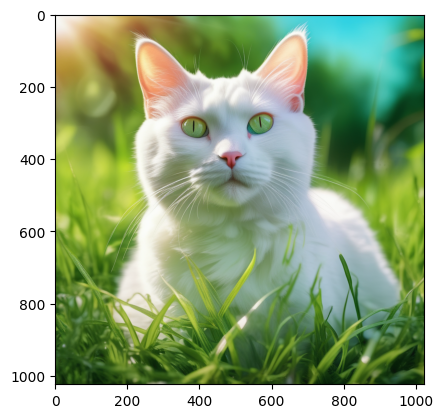

In [14]:
print(latents.min(), latents.max())
with torch.no_grad():
    image = (vae.decode(latents.float() / vae.config.scaling_factor).sample + 1.0) / 2.0
print(image.shape)

image = image.squeeze(0).permute((1, 2, 0)).float().cpu().numpy()
image = np.clip(image, 0, 1)

plt.imshow(image)
plt.show()